In [1]:
# Qubit Operator Algebra, Density Matrix, Bloch Sphere, Coherence, Entanglement Etc.

'''
This notebook demonstrates key concepts in quantum information:

1. Pauli Matrices
2. Qubit States
3. Density Matrices
4. Purity
5. Quantum Coherence
6. Entanglement
7. Bloch Sphere Representation

The goal is to provide an **interactive and visual understanding** of these concepts.

Mathematical tools used:
- NumPy (linear algebra)
- Matplotlib (visualization)
'''

'\nThis notebook demonstrates key concepts in quantum information:\n\n1. Pauli Matrices\n2. Qubit States\n3. Density Matrices\n4. Purity\n5. Quantum Coherence\n6. Entanglement\n7. Bloch Sphere Representation\n\nThe goal is to provide an **interactive and visual understanding** of these concepts.\n\nMathematical tools used:\n- NumPy (linear algebra)\n- Matplotlib (visualization)\n'

In [2]:
# Install Libraries (QuTiP is useful for Bloch Sphere)
!pip install qutip --quiet

import numpy as np
import matplotlib.pyplot as plt
from qutip import Bloch

!pip install qutip ipywidgets --quiet
from ipywidgets import interact, FloatSlider
from IPython.display import display

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.4 MB/s eta 0:00:00


In [3]:
# Pauli Matrices
"""
Pauli matrices (along with Identity) form a basis for all 2×2 Hermitian operators.

σx = [[0,1],
      [1,0]]

σy = [[0,-i],
      [i,0]]

σz = [[1,0],
      [0,-1]]
"""

sigma_x = np.array([[0,1],[1,0]])
sigma_y = np.array([[0,-1j],[1j,0]])
sigma_z = np.array([[1,0],[0,-1]])

I = np.eye(2)

print("Sigma X\n",sigma_x)
print("\nSigma Y\n",sigma_y)
print("\nSigma Z\n",sigma_z)

Sigma X
 [[0 1]
 [1 0]]

Sigma Y
 [[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

Sigma Z
 [[ 1  0]
 [ 0 -1]]


In [4]:
# Properties of Pauli Matrices

"""
Important properties:

1. σ_i^2 = I
2. {σ_i, σ_j} = 2δ_ij I (anticommutation)
3. [σ_i, σ_j] = 2i ε_ijk σ_k (commutation)
"""

print("σx^2 =\n", sigma_x @ sigma_x)
print("\nσy^2 =\n", sigma_y @ sigma_y)
print("\nσz^2 =\n", sigma_z @ sigma_z)

print("\nAnticommutator σxσy + σyσx =\n", sigma_x@sigma_y + sigma_y@sigma_x)

print("\nCommutator σxσy - σyσx =\n", sigma_x@sigma_y - sigma_y@sigma_x)

σx^2 =
 [[1 0]
 [0 1]]

σy^2 =
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

σz^2 =
 [[1 0]
 [0 1]]

Anticommutator σxσy + σyσx =
 [[0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

Commutator σxσy - σyσx =
 [[0.+2.j 0.+0.j]
 [0.+0.j 0.-2.j]]


In [5]:
# Eigenvectors and Eigenvalues of the Pauli Matrices

"""
Pauli matrices have eigenvalues ±1.

They represent measurements along x, y, z directions.
"""

eigvals, eigvecs = np.linalg.eig(sigma_y)

print("Eigenvalues of σy:", eigvals)
print("\nEigenvectors:\n", eigvecs)

Eigenvalues of σy: [ 1.+0.j -1.+0.j]

Eigenvectors:
 [[-0.        -0.70710678j  0.70710678+0.j        ]
 [ 0.70710678+0.j          0.        -0.70710678j]]


In [6]:
# Define Qubit State

"""
A general qubit:

|ψ> = α|0> + β|1>

with normalization:

|α|² + |β|² = 1
"""

alpha = 1/np.sqrt(2)
beta = 1/np.sqrt(2)

psi = np.array([[alpha],[beta]])

print("Qubit state |ψ>:\n", psi)

Qubit state |ψ>:
 [[0.70710678]
 [0.70710678]]


In [7]:
# Density Matrix of the Pure State

"""
Density matrix definition:

ρ = |ψ><ψ|
"""

rho = psi @ psi.conj().T

print("Density matrix:\n", rho)

Density matrix:
 [[0.5 0.5]
 [0.5 0.5]]


In [8]:
# Properties of the Density Matrices

"""
Density matrix properties:

1. Hermitian
2. Trace = 1
3. Positive semi-definite
"""

print("Trace:", np.trace(rho))
print("Trace of square:", np.trace(rho @ rho))
print("Hermitian check:", np.allclose(rho, rho.conj().T))

eigvals = np.linalg.eigvals(rho)
print("Eigenvalues:", eigvals)

Trace: 0.9999999999999998
Trace of square: 0.9999999999999996
Hermitian check: True
Eigenvalues: [1. 0.]


In [9]:
# Purity of Quantum State

"""
Purity measure:

Purity = Tr(ρ²)

Pure state → Purity = 1
Mixed state → Purity < 1
"""

purity = np.trace(rho @ rho)

print("Purity =", purity)

Purity = 0.9999999999999996


In [10]:
# Mixed State Example

"""
Mixed state:
ρ = p |0><0| + (1-p)|1><1|
"""

p = 0.6

rho_mixed = np.array([
    [p,0],
    [0,1-p]
])

print("Mixed state density matrix:\n", rho_mixed)

purity = np.trace(rho_mixed @ rho_mixed)
print("\nPurity:", purity)

Mixed state density matrix:
 [[0.6 0. ]
 [0.  0.4]]

Purity: 0.52


In [11]:
# Quantum Coherence

"""
Coherence corresponds to the OFF-DIAGONAL terms of the density matrix.

ρ = [[ρ00 , ρ01],
     [ρ10 , ρ11]]

ρ01 and ρ10 represent coherence.
"""

coherence = 2*abs(rho[0,1])

print("Coherence magnitude:", coherence)

Coherence magnitude: 0.9999999999999998


In [12]:
# Example of Phase Damping (Loss of Coherence)
"""
Phase damping removes coherence.

ρ' = [[ρ00 , γρ01],
      [γρ10 , ρ11]]
"""

gamma = 0.2

rho_damped = np.array([
    [rho[0,0], gamma*rho[0,1]],
    [gamma*rho[1,0], rho[1,1]]
])

print("Density matrix after decoherence:\n", rho_damped)

Density matrix after decoherence:
 [[0.5 0.1]
 [0.1 0.5]]


In [13]:
# Two Qubit System

"""
Now we explore entanglement.

Basis:

|00>, |01>, |10>, |11>
"""

zero = np.array([[1],[0]])
one = np.array([[0],[1]])

basis00 = np.kron(zero,zero)
basis11 = np.kron(one,one)

In [14]:
# Bell State

"""
Bell state:

|Φ+> = (|00> + |11>) / √2
"""

bell = (basis00 + basis11)/np.sqrt(2)

rho_bell = bell @ bell.conj().T

print("Bell state density matrix:\n", rho_bell)

Bell state density matrix:
 [[0.5 0.  0.  0.5]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.5 0.  0.  0.5]]


In [15]:
# Reduced Density Matrix of the Bell State

"""
Trace out second qubit.

Entanglement test:
Each qubit individually appears maximally mixed.
"""

rho_A = np.array([
    [0.5,0],
    [0,0.5]
])

print("Reduced density matrix:\n", rho_A)

Reduced density matrix:
 [[0.5 0. ]
 [0.  0.5]]


In [16]:
# Purity of the reduced states

purity = np.trace(rho_A @ rho_A)

print("Purity of subsystem:", purity)

# Purity = 0.5, indicating maximal mixedness due to entanglement.

Purity of subsystem: 0.5


In [17]:
# Bloch Vector from Density Matrix

"""
Any qubit density matrix can be written as:

ρ = (1/2)(I + r·σ)

where r = Bloch vector
"""

rx = np.trace(rho @ sigma_x).real
ry = np.trace(rho @ sigma_y).real
rz = np.trace(rho @ sigma_z).real

bloch_vector = np.array([rx,ry,rz])

print("Bloch vector:", bloch_vector)
print("Length:", np.linalg.norm(bloch_vector))

Bloch vector: [1. 0. 0.]
Length: 0.9999999999999998


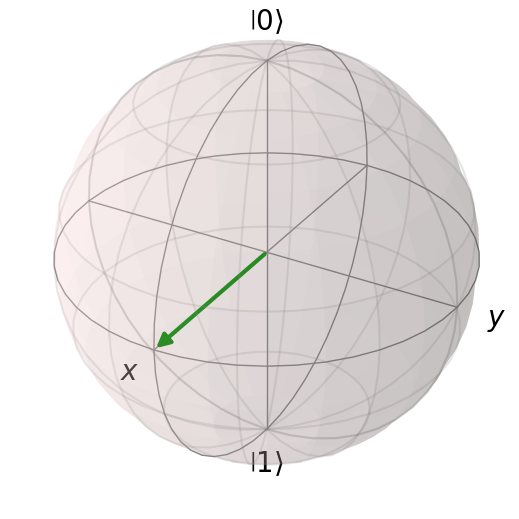

In [18]:
# Bloch Sphere Visualization

b = Bloch()

b.add_vectors(bloch_vector)

b.show()

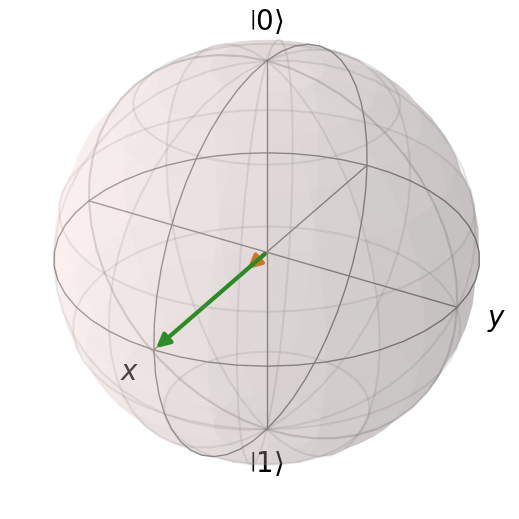

In [19]:
# Bloch vector after Decoherence

rx = np.trace(rho_damped @ sigma_x).real
ry = np.trace(rho_damped @ sigma_y).real
rz = np.trace(rho_damped @ sigma_z).real

bloch_vector2 = [rx,ry,rz]

b = Bloch()
b.add_vectors(bloch_vector)
b.add_vectors(bloch_vector2)

b.show()

In [20]:
# Bloch Sphere: Helper Functions

"""
Utility functions for Bloch sphere visualization
"""

sigma_x = np.array([[0,1],[1,0]])
sigma_y = np.array([[0,-1j],[1j,0]])
sigma_z = np.array([[1,0],[0,-1]])
I = np.eye(2)


def state_from_angles(theta, phi):
    """
    Construct qubit state:

    |ψ> = cos(θ/2)|0> + e^{iφ} sin(θ/2)|1>
    """

    alpha = np.cos(theta/2)
    beta = np.exp(1j*phi)*np.sin(theta/2)

    psi = np.array([[alpha],[beta]])

    return psi


def density_matrix(psi):
    """
    Compute density matrix ρ = |ψ><ψ|
    """

    return psi @ psi.conj().T


def bloch_vector(rho):
    """
    Compute Bloch vector components

    r_i = Tr(ρ σ_i)
    """

    rx = np.trace(rho @ sigma_x).real
    ry = np.trace(rho @ sigma_y).real
    rz = np.trace(rho @ sigma_z).real

    return np.array([rx,ry,rz])

In [21]:
# Interactive Bloch Sphere with theta and phi

def interactive_bloch(theta, phi):

    psi = state_from_angles(theta, phi)
    rho = density_matrix(psi)

    r = bloch_vector(rho)

    b = Bloch()
    b.add_vectors(r)

    b.show()


interact(
    interactive_bloch,
    theta=FloatSlider(min=0,max=np.pi,step=0.05,value=np.pi/2),
    phi=FloatSlider(min=0,max=2*np.pi,step=0.05,value=0)
)

# Changing θ --> Moves state north–south
# Changing φ --> Rotates state around z-axis

interactive(children=(FloatSlider(value=1.5707963267948966, description='theta', max=3.141592653589793, step=0…

<function __main__.interactive_bloch(theta, phi)>

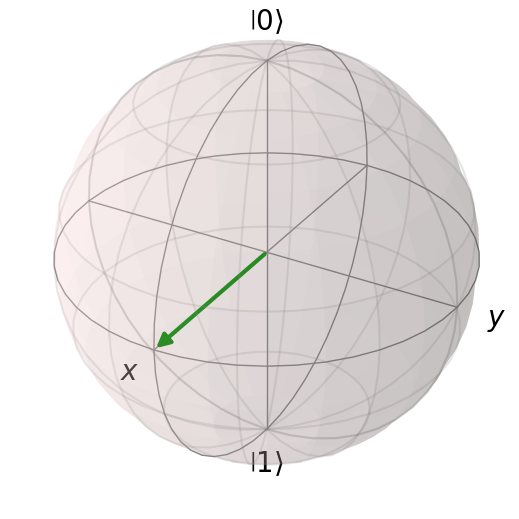

In [22]:
# Rotations around Z-Axis
# This simulates a unitary evolution: U=e−iθσz​/2

import time
from IPython.display import clear_output

def animate_rotation_z():

    theta = np.pi/2
    psi = state_from_angles(theta,0)

    for phi in np.linspace(0,2*np.pi,60):

        psi = state_from_angles(theta,phi)
        rho = density_matrix(psi)
        r = bloch_vector(rho)

        clear_output(wait=True)

        b = Bloch()
        b.add_vectors(r)
        b.show()

        time.sleep(0.1)


animate_rotation_z()

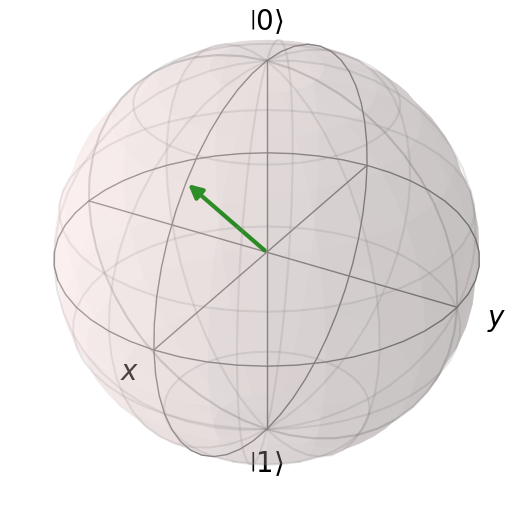

In [23]:
# Animated Rotations around X-axis
# This simulates: U=e−iθσx​/2

def rotation_x(theta):

    return np.cos(theta/2)*I - 1j*np.sin(theta/2)*sigma_x


def animate_rotation_x():

    psi = state_from_angles(np.pi/4,0)

    for t in np.linspace(0,2*np.pi,60):

        U = rotation_x(t)

        psi_t = U @ psi
        rho = density_matrix(psi_t)

        r = bloch_vector(rho)

        clear_output(wait=True)

        b = Bloch()
        b.add_vectors(r)
        b.show()

        time.sleep(0.1)


animate_rotation_x()

In [24]:
# Visualizing Bloch Sphere Coordinates
# This will help us see how θ and φ map to Bloch vector components.
# x=sinθcosϕ      𝑦=sinθsin⁡ϕ       z=cosθ

def bloch_coordinates(theta,phi):

    x = np.sin(theta)*np.cos(phi)
    y = np.sin(theta)*np.sin(phi)
    z = np.cos(theta)

    print("Bloch vector:")
    print("x =",x)
    print("y =",y)
    print("z =",z)


interact(
    bloch_coordinates,
    theta=FloatSlider(min=0,max=np.pi,step=0.05,value=np.pi/2),
    phi=FloatSlider(min=0,max=2*np.pi,step=0.05,value=0)
)

interactive(children=(FloatSlider(value=1.5707963267948966, description='theta', max=3.141592653589793, step=0…

<function __main__.bloch_coordinates(theta, phi)>

In [25]:
# Summary

'''
Key Takeaways
State: ∣ψ⟩=cos(θ/2)∣0⟩+eiϕsin(θ/2)∣1⟩
Bloch Vector: r=(sinθcosϕ,sinθsinϕ,cosθ)

Pauli matrices: Form basis for qubit operators

Density matrices: Describe both pure and mixed states

Purity: Measures classical uncertainty

Coherence: Comes from off-diagonal terms

Bloch sphere: Visual representation of qubit states

Entanglement: Subsystems appear mixed even if the global state is pure
'''

'\nKey Takeaways\nState: ∣ψ⟩=cos(θ/2)∣0⟩+eiϕsin(θ/2)∣1⟩\nBloch Vector: r=(sinθcosϕ,sinθsinϕ,cosθ)\n\nPauli matrices: Form basis for qubit operators\n\nDensity matrices: Describe both pure and mixed states\n\nPurity: Measures classical uncertainty\n\nCoherence: Comes from off-diagonal terms\n\nBloch sphere: Visual representation of qubit states\n\nEntanglement: Subsystems appear mixed even if the global state is pure\n'

In [26]:
"""
MCQ 1

What is the value of σx² ?

σx = [[0,1],
      [1,0]]

Options:
A) σx
B) Identity
C) -Identity
D) Zero matrix
"""
##Answer: B) IDentity


'\nMCQ 1\n\nWhat is the value of σx² ?\n\nσx = [[0,1],\n      [1,0]]\n\nOptions:\nA) σx\nB) Identity\nC) -Identity\nD) Zero matrix\n'

In [27]:
"""
MCQ 2

What are the eigenvalues of σz ?

Options:
A) {0,1}
B) {+1,-1}
C) {i,-i}
D) {2,-2}
"""

'\nMCQ 2\n\nWhat are the eigenvalues of σz ?\n\nOptions:\nA) {0,1}\nB) {+1,-1}\nC) {i,-i}\nD) {2,-2}\n'

In [35]:
eigvals_z, eigvecs_z = np.linalg.eig(sigma_z)
print("Eigenvalues of σz:", eigvals_z)

Eigenvalues of σz: [ 1. -1.]


In [28]:
"""
MCQ 3

For the state:

|ψ> = (|0> + |1>) / √2

What is the density matrix?

Options:
A) [[1,0],[0,0]]
B) [[0.5,0],[0,0.5]]
C) [[0.5,0.5],[0.5,0.5]]
D) [[0.5,-0.5],[-0.5,0.5]]
"""

'\nMCQ 3\n\nFor the state:\n\n|ψ> = (|0> + |1>) / √2\n\nWhat is the density matrix?\n\nOptions:\nA) [[1,0],[0,0]]\nB) [[0.5,0],[0,0.5]]\nC) [[0.5,0.5],[0.5,0.5]]\nD) [[0.5,-0.5],[-0.5,0.5]]\n'

In [39]:
print(rho)

[[0.5 0.5]
 [0.5 0.5]]


In [29]:
"""
MCQ 4

Given density matrix:

ρ = [[0.5,0],
     [0,0.5]]

What is the purity Tr(ρ²)?

Options:
A) 1
B) 0.75
C) 0.5
D) 0
"""

##answer: C) 0.5

'\nMCQ 4\n\nGiven density matrix:\n\nρ = [[0.5,0],\n     [0,0.5]]\n\nWhat is the purity Tr(ρ²)?\n\nOptions:\nA) 1\nB) 0.75\nC) 0.5\nD) 0\n'

In [30]:
"""
MCQ 5

For a pure qubit state, what is the magnitude of the Bloch vector?

Options:
A) 0
B) 0.5
C) 1
D) 2
"""
##answer: C) 1

'\nMCQ 5\n\nFor a pure qubit state, what is the magnitude of the Bloch vector?\n\nOptions:\nA) 0\nB) 0.5\nC) 1\nD) 2\n'

In [31]:
"""
MCQ 6

Which element of the density matrix represents quantum coherence?

ρ = [[ρ00 , ρ01],
     [ρ10 , ρ11]]

Options:
A) ρ00
B) ρ11
C) ρ01 and ρ10
D) Trace
"""

##Answer: C) ρ01 and ρ10

'\nMCQ 6\n\nWhich element of the density matrix represents quantum coherence?\n\nρ = [[ρ00 , ρ01],\n     [ρ10 , ρ11]]\n\nOptions:\nA) ρ00\nB) ρ11\nC) ρ01 and ρ10\nD) Trace\n'

In [32]:
"""
MCQ 7

A Bell state is pure globally.

But the reduced density matrix of one qubit is:

ρ = [[0.5,0],
     [0,0.5]]

What is the purity of the subsystem?

Options:
A) 1
B) 0.75
C) 0.5
D) 0
"""

##ANswer: C) 0.5

'\nMCQ 7\n\nA Bell state is pure globally.\n\nBut the reduced density matrix of one qubit is:\n\nρ = [[0.5,0],\n     [0,0.5]]\n\nWhat is the purity of the subsystem?\n\nOptions:\nA) 1\nB) 0.75\nC) 0.5\nD) 0\n'

In [33]:
"""
MCQ 8

Given θ = π/2 and φ = 0

What is the Bloch vector?

Options:
A) (1,0,0)
B) (0,1,0)
C) (0,0,1)
D) (0,0,-1)
"""

##Answer: A

'\nMCQ 8\n\nGiven θ = π/2 and φ = 0\n\nWhat is the Bloch vector?\n\nOptions:\nA) (1,0,0)\nB) (0,1,0)\nC) (0,0,1)\nD) (0,0,-1)\n'